In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt




In [ ]:
one_anc = np.load("output/Single_ancilla_Different_Order/PPEEE/t1_280.0_t2_330.0/fidelity_array.npy")
two_anc = np.load("output/Two_Ancillae_PPEEE/t1_280.0_t2_330.0/fidelity_array.npy")
three_anc = np.load(f"output/Three_PPEEE/t1_280.0_t2_330.0/fidelity_array.npy")

In [26]:
print(one_anc.shape)
print(two_anc.shape)
print(three_anc.shape)

(448,)
(288,)
(225,)


In [3]:
time_scale1 = np.linspace(0, .03 * one_anc.shape[0], one_anc.shape[0])
time_scale2 = np.linspace(0, .03 * two_anc.shape[0], two_anc.shape[0])
time_scale3 = np.linspace(0, .03 * three_anc.shape[0], three_anc.shape[0])

Text(0.5, 0.98, 'Fidelity Comparison of Circuit with Different Numbers of Ancillae')

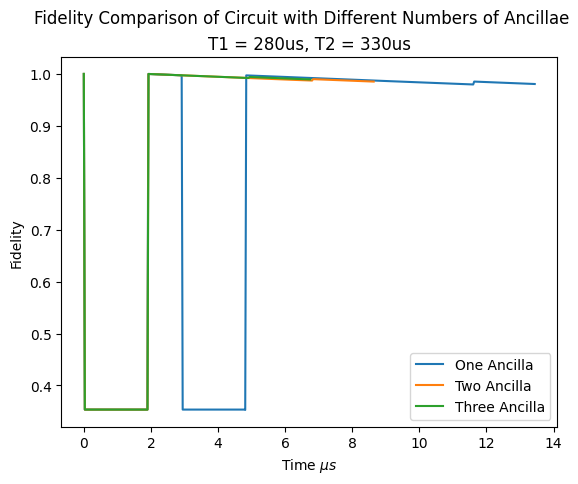

In [5]:
plt.plot(time_scale1,one_anc, label="One Ancilla")
plt.plot(time_scale2,two_anc, label="Two Ancilla")
plt.plot(time_scale3,three_anc, label="Three Ancilla")

plt.legend()
plt.xlabel(r"Time $\mu s$")
plt.ylabel("Fidelity")
plt.title("T1 = 280us, T2 = 330us")
plt.suptitle("Fidelity Comparison of Circuit with Different Numbers of Ancillae")

In [6]:
print(one_anc[-1])
print(two_anc[-1])
print(three_anc[-1])

0.9805873367066543
0.9852211548111601
0.9893473632917044


In [ ]:
EEEPP_results = np.load("output/Single_Ancilla_Different_Order/EEEPP/t1_280.0_t2_330.0/fidelity_array.npy")
EEPPE_results = np.load("output/Single_Ancilla_Different_Order/EEPPE/t1_280.0_t2_330.0/fidelity_array.npy")
EPPEE_results = np.load("output/Single_Ancilla_Different_Order/EPPEE/t1_280.0_t2_330.0/fidelity_array.npy")
PPEEE_results = np.load("output/Single_Ancilla_Different_Order/PPEEE/t1_280.0_t2_330.0/fidelity_array.npy")
PEEEP_results = np.load("output/Single_Ancilla_Different_Order/PEEEP/t1_280.0_t2_330.0/fidelity_array.npy")
PEEPE_results = np.load("output/Single_Ancilla_Different_Order/PEEPE/t1_280.0_t2_330.0/fidelity_array.npy")
PEPEE_results = np.load("output/Single_Ancilla_Different_Order/PEPEE/t1_280.0_t2_330.0/fidelity_array.npy")
EPEPE_results = np.load("output/Single_Ancilla_Different_Order/EPEPE/t1_280.0_t2_330.0/fidelity_array.npy")
EEPEP_results = np.load("output/Single_Ancilla_Different_Order/EEPEP/t1_280.0_t2_330.0/fidelity_array.npy")
EPEEP_results = np.load("output/Single_Ancilla_Different_Order/EPEEP/t1_280.0_t2_330.0/fidelity_array.npy")

results = np.array([EEEPP_results, EEPPE_results, EPPEE_results, PPEEE_results, PEEEP_results, PEEPE_results, PEPEE_results, EPEPE_results, EEPEP_results, EPEEP_results, PEEPE_results])

In [12]:
for i in results:
    print(i.shape)

(448,)
(448,)
(448,)
(448,)
(448,)
(448,)
(448,)
(448,)
(448,)
(448,)
(448,)


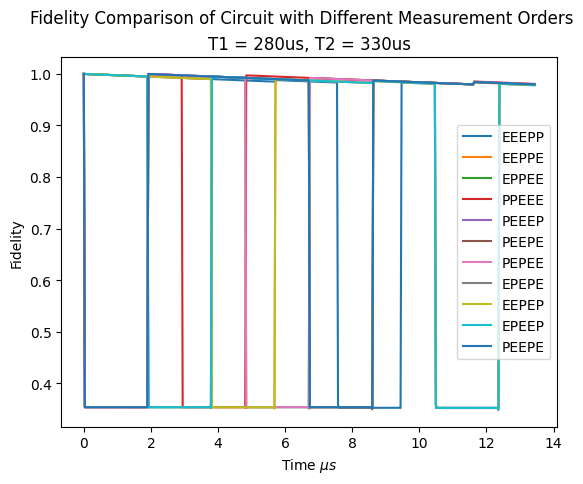

In [ ]:
time_scale = np.linspace(0, .03 * results[0].shape[0], results[0].shape[0])
plt.plot(time_scale, results.T, label=["EEEPP", "EEPPE", "EPPEE", "PPEEE", "PEEEP", "PEEPE", "PEPEE", "EPEPE", "EEPEP", "EPEEP"])
plt.legend()
plt.xlabel(r"Time $\mu s$")
plt.ylabel("Fidelity")
plt.title("T1 = 280us, T2 = 330us") 
plt.suptitle("Fidelity Comparison of Circuit with Different Measurement Orders")
final_fidelities = results[:,-1]

In [14]:
print(final_fidelities)
print(np.argmin(final_fidelities))
print(np.argmax(final_fidelities))


[0.97821255 0.97887987 0.97972272 0.98058734 0.9793413  0.97970691
 0.98014058 0.97928708 0.97849595 0.97891344 0.97970691]
0
3


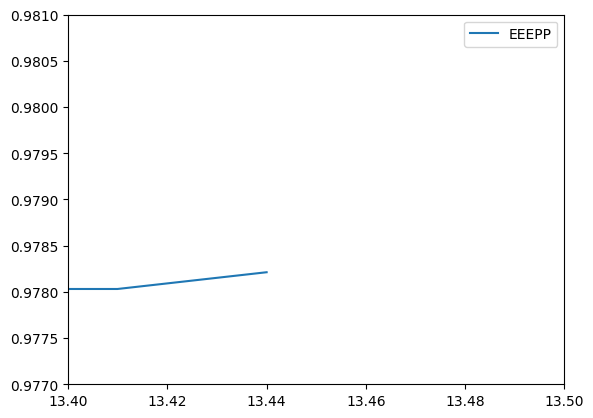

In [13]:
plt.plot(time_scale,results.T[:,0], label=["EEEPP", "EEPPE", "EPPEE", "PPEEE", "PEEEP", "PEEPE", "PEPEE", "EPEPE", "EEPEP", "EPEEP", "PEEPE"][0])
plt.xlim(13.4,13.5)
plt.ylim(.977,.981)
plt.legend()

In [2]:
from quantum_logical.experiment_runner import ExperimentRunner
from quantum_logical.gates import hadamard_operator
import qutip as qt

initial_state = qt.tensor([hadamard_operator(3) *qt.basis(3,0)]*3)
fidelities = {4:[], 5:[], 6:[]}
states = {4:[], 5:[], 6:[]}
for num_qudits in range(4, 7):

    initial_setup = qt.tensor(initial_state, *([qt.basis(3,0)]*(num_qudits-3)))
    rho_i = qt.ket2dm(initial_setup)

    trotterer = ExperimentRunner.generate_trotterizer(trotter_dt=.03, T1= 280, T2=330, dim=3, num_qubits=num_qudits)

    id_gate = [qt.tensor([qt.qeye(3) for _ in range(num_qudits)])]

    resulting_states = ExperimentRunner.run_unitary_circuit(trotterer,id_gate,rho_i, [3])

    fidelity = [qt.fidelity(state.ptrace([0,1,2]), qt.ket2dm(initial_state)) for state in resulting_states]
    fidelities[num_qudits] = fidelity

    states[num_qudits] = [state.ptrace([0,1,2]) for state in resulting_states]
 


c:\Users\Warren\Desktop\QuantumLogicalSimulator\.venv\Lib\site-packages\qutip\core\data\expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [1]:
import matplotlib.pyplot as plt
import numpy as np


time_scale = np.linspace(0, .03*101, 101)

plt.plot(time_scale, fidelities[4], label="4 Qudits")
plt.plot(time_scale, fidelities[5], label="5 Qudits")
plt.plot(time_scale, fidelities[6], label="6 Qudits")
plt.legend()
plt.xlabel(r"Time $\mu s$")
plt.ylabel("Fidelity")
plt.title("Fidelity of 3 microseconds of identity with T1 = 280us, T2 = 330us")


NameError: name 'fidelities' is not defined

In [8]:
probabilities = []
for i, j in states.items():
    probabilities.append(j[-1].diag().real)

print(probabilities)


[array([1.25001329e-01, 3.33919197e-04, 1.24666524e-01, 3.33919197e-04,
       8.83134059e-07, 3.33033743e-04, 1.24666524e-01, 3.33033743e-04,
       1.24332606e-01, 3.33919197e-04, 8.83134059e-07, 3.33033743e-04,
       8.83134059e-07, 2.31220352e-09, 8.80815843e-07, 3.33033743e-04,
       8.80815843e-07, 3.32150613e-04, 1.24666524e-01, 3.33033743e-04,
       1.24332606e-01, 3.33033743e-04, 8.80815843e-07, 3.32150613e-04,
       1.24332606e-01, 3.32150613e-04, 1.23999574e-01]), array([1.25000851e-01, 2.67276400e-04, 1.24733007e-01, 2.67276400e-04,
       5.65798879e-07, 2.66709412e-04, 1.24733007e-01, 2.66709412e-04,
       1.24465732e-01, 2.67276400e-04, 5.65798879e-07, 2.66709412e-04,
       5.65798879e-07, 1.18569521e-09, 5.64610718e-07, 2.66709412e-04,
       5.64610718e-07, 2.66143615e-04, 1.24733007e-01, 2.66709412e-04,
       1.24465732e-01, 2.66709412e-04, 5.64610718e-07, 2.66143615e-04,
       1.24465732e-01, 2.66143615e-04, 1.24199023e-01]), array([1.25000591e-01, 2.22808793

Text(0.5, 1.0, 'Fidelity Comparison of Partial Erasure Methods with T1 = 280us, T2 = 330us')

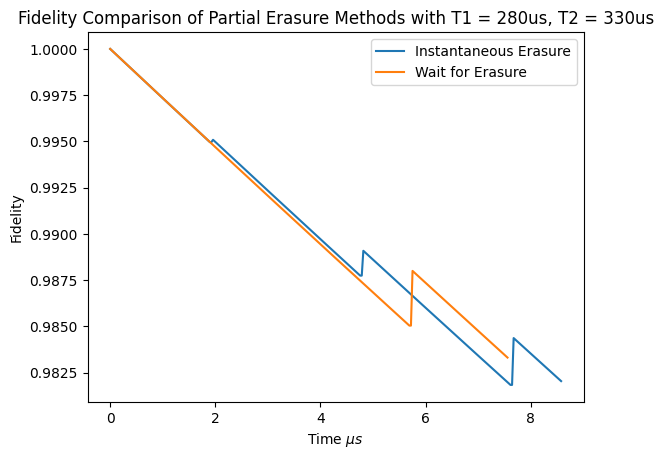

In [4]:
instant = np.load("output/PartialErasureInstant/t1_280.0_t2_330.0/fidelity_array.npy")
wait = np.load("output/PartialErasureWait/t1_280.0_t2_330.0/fidelity_array.npy")

time_scale_inst = np.linspace(0, .03 * instant.shape[0], instant.shape[0])
time_scale_wait = np.linspace(0, .03 * wait.shape[0], wait.shape[0])
plt.plot(time_scale_inst, instant, label="Instantaneous Erasure")
plt.plot(time_scale_wait, wait, label="Wait for Erasure")
plt.legend()
plt.xlabel(r"Time $\mu s$")
plt.ylabel("Fidelity")
plt.title("Fidelity Comparison of Partial Erasure Methods with T1 = 280us, T2 = 330us")
